# S04: Atom Mapping as Graph Morphism: MCS and ITS Equivalence

Authors:
- [Tieu-Long Phan](https://tieulongphan.github.io/), Leipzig University - Southern Denmark University

## Aim of this talktorial

This talktorial (**S04**) expands application of MCS in **S03** to find atom mapping and construct ITS graph to compare atom map

Concretely, we focus on:

1. **MCS-based atom mapping**  
   Building an atom correspondence by aligning maximum common substructures
   between reactants and products.

2. **Attention-guided atom mapping (RXNMapper)**  
   Running RXNMapper to obtain mapped reaction SMILES and extracting atom maps.

3. **ITS graph construction**  
   Encoding a mapped reaction as an **Imaginary Transition State (ITS)** graph.

4. **Map comparison via graph isomorphism**  
   Comparing different atom maps by testing **ITS isomorphism**, making the
   comparison invariant to atom-map IDs.

---

## Learning outcomes

After completing this talktorial, you will be able to:

- Construct a simple **MCS-based atom map** in code.
- Run **RXNMapper** and parse mapped reaction SMILES.
- Build an **ITS graph** from a mapped reaction.
- Decide whether two atom maps are equivalent by checking
  **ITS graph isomorphism**.

---

## Outline

- [0. Setup & Data](#0-setup--data)
- [1. Atom mapping](#1-atom-mapping)
- [2. ITS graph construction](#2-its-graph-construction)
- [3. Ensemble atom map](#3-ensemble-atom-map)
- [4. Discussion](#4-discussion)
- [5. Quiz](#5-quiz)
- [6. References](#6-references)

(0-setup--data)=
## 0. Setup & Data

In [1]:
import rdkit
import pandas as pd
import networkx as nx
import warnings

warnings.filterwarnings("ignore")

print("RDKit:", rdkit.__version__)
print("NetworkX:", nx.__version__)

try:
    from rxnmapper import RXNMapper

    _HAS_RXNMAPPER = True
    print("rxnmapper: available")
except Exception:
    _HAS_RXNMAPPER = False
    print("rxnmapper: NOT available -> will skip RXNMapper cells")

data = pd.read_csv('./data/reaction_maps.csv')

RDKit: 2025.09.3
NetworkX: 3.6.1
rxnmapper: available


(1-atom-mapping)=
## 1. Atom mapping
### 1.1. Alignment method

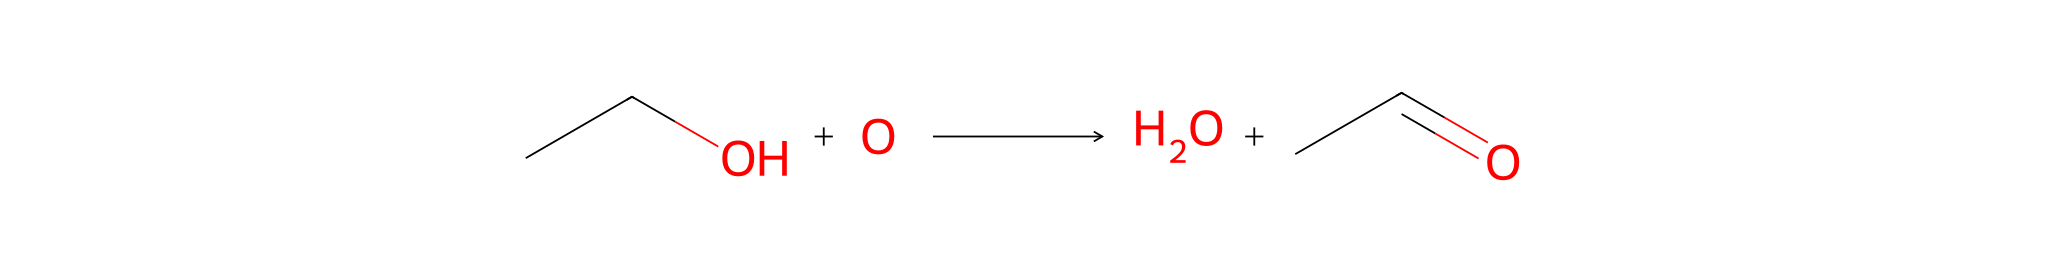

In [ ]:
from synedu.Utils.rxn_vis import visualize_reaction
from IPython.display import SVG


rsmi = 'CCO.[O]>>O.CC=O'

svg = visualize_reaction(
    rsmi,
    svg=True,
    highlight_changes=True,
    legend="Oxidation",
)
display(SVG(svg))

Now we convert them into reactant and product graphs using `rsmi_to_graph` from `SynKit`

<Axes: >

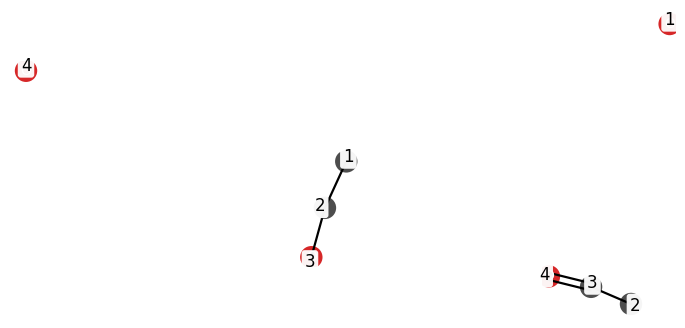

In [3]:
import matplotlib.pyplot as plt
from synkit.IO import rsmi_to_graph
from synedu.Utils.vis import draw_molecular_graph

rsmi = 'CCO.[O]>>O.CC=O'
r, p = rsmi_to_graph(rsmi, drop_non_aam=False, use_index_as_atom_map=False)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
draw_molecular_graph(r, show_indices=True, ax=ax[0])
draw_molecular_graph(p, show_indices=True, ax=ax[1])

We now develop `mcs_networkx` to identify the Maximum Common Substructure (MCS).
Note that in a reaction context, **bonds may be formed or broken** between
reactants and products. Therefore, bond attributes should **not** be used
as matching constraints (`edge_attrs`), and the MCS is computed based on
atom-level corr

In [4]:
import networkx as nx
from itertools import combinations
from networkx.algorithms.isomorphism import GraphMatcher, generic_node_match


def mcs_networkx(
    G1: nx.Graph,
    G2: nx.Graph,
    *,
    node_attrs=("element",),
    edge_attrs=(),
    require_connected=False,  # False => maximum DISCONNECTED common subgraph
    prune_symmetry=True,  # cheap symmetry pruning
    max_solutions=200,
):
    """
    Maximum common subgraph (MCS) via NetworkX GraphMatcher.

    - If require_connected=False: returns a maximum DISCONNECTED common subgraph (MDCS).
    - If require_connected=True: returns a maximum CONNECTED common subgraph.

    Returns
    -------
    list[dict[int, int]]
        List of maximum-size mappings (G1_subgraph -> G2_subgraph).
    """
    # --- node/edge matchers ---
    node_match = generic_node_match(
        list(node_attrs),
        [None] * len(node_attrs),
        [lambda a, b: a == b] * len(node_attrs),
    )

    edge_match = None
    if edge_attrs:
        edge_match = generic_node_match(
            list(edge_attrs),
            [None] * len(edge_attrs),
            [lambda a, b: a == b] * len(edge_attrs),
        )

    # --- search subgraphs of smaller graph for speed ---
    pattern, host, pattern_is_G1 = _prepare_orientation(G1, G2)

    pat_nodes = list(pattern.nodes())
    n = len(pat_nodes)

    best_k = 0
    candidates = []

    for k in range(n, 0, -1):
        level = []

        for subset in combinations(pat_nodes, k):
            sub_pat = pattern.subgraph(subset).copy()

            if (
                require_connected
                and sub_pat.number_of_nodes() > 1
                and not nx.is_connected(sub_pat)
            ):
                continue

            gm = GraphMatcher(
                host,
                sub_pat,
                node_match=node_match,
                edge_match=edge_match,
            )

            for iso_map in gm.subgraph_isomorphisms_iter():
                # GraphMatcher(host, pattern) yields host->pattern; invert to pattern->host
                inv = {pat: h for h, pat in iso_map.items()}
                level.append(inv)
                if len(level) >= max_solutions:
                    break
            if len(level) >= max_solutions:
                break

        if level:
            best_k = k
            candidates = level
            break

    if not candidates:
        return []

    # candidates currently map: pattern -> host
    # convert to G1 -> G2 orientation if needed
    if not pattern_is_G1:
        candidates = [{h: pat for pat, h in m.items()} for m in candidates]

    if prune_symmetry:
        candidates = _prune_by_node_sets(candidates)

    # keep only max-size
    candidates = [m for m in candidates if len(m) == best_k]
    return candidates


def _prepare_orientation(G1: nx.Graph, G2: nx.Graph):
    """Return (pattern, host, pattern_is_G1) where pattern is the smaller graph."""
    if G1.number_of_nodes() <= G2.number_of_nodes():
        return G1, G2, True
    return G2, G1, False


def _prune_by_node_sets(maps):
    """
    Cheap symmetry pruning: keep one mapping per (domain-set, image-set).
    Collapses many benzene-like symmetric mappings in practice.
    """
    seen = set()
    out = []
    for m in maps:
        key = (tuple(sorted(m.keys())), tuple(sorted(m.values())))
        if key not in seen:
            seen.add(key)
            out.append(m)
    return out

In [5]:
maps = mcs_networkx(
    r,
    p,
    node_attrs=("element",),
    edge_attrs=None,
    require_connected=False,
    prune_symmetry=True,
)
maps

[{1: 2, 2: 3, 3: 4, 4: 1}]

Now we can just add `atom_maps` to node attribute

In [6]:
for rid, pid in maps[0].items():
    r.nodes[rid]["atom_map"] = rid
    p.nodes[pid]["atom_map"] = rid

**Q1 — Assign atom maps from reactant–product alignment**

You are given a node mapping from a **reactant graph** `r` to a
**product graph** `p`, obtained from an MCS-based alignment.
Your task is to assign **atom-map numbers** to the corresponding atoms
on both sides of the reaction.

The convention is that each matched atom pair shares the **same
`atom_map` label**, which is taken from the reactant node index.

---

<details> <summary><b>Solution:</b></summary>

```python
def assign_atom_map_r_to_p(r, p, mapping):
    """
    Assign atom_map attributes on both reactant and product graphs
    using an r -> p node mapping.

    Parameters
    ----------
    r : nx.Graph
        Reactant graph
    p : nx.Graph
        Product graph
    mapping : dict[int, int]
        Mapping r_index -> p_index
    """
    for r_idx, p_idx in mapping.items():
        if r_idx not in r:
            raise KeyError(f"Node {r_idx} not found in reactant graph")
        if p_idx not in p:
            raise KeyError(f"Node {p_idx} not found in product graph")

        # assign the same atom-map label to matched atoms
        r.nodes[r_idx]["atom_map"] = r_idx
        p.nodes[p_idx]["atom_map"] = r_idx

```

</details>

In [7]:
def assign_atom_map_r_to_p(r, p, mapping):
    """
    Assign atom_map attributes on both reactant and product graphs
    using an r -> p node mapping.

    Parameters
    ----------
    r : nx.Graph
        Reactant graph
    p : nx.Graph
        Product graph
    mapping : dict[int, int]
        Mapping r_index -> p_index
    """
    for r_idx, p_idx in mapping.items():
        if r_idx not in r:
            raise KeyError(f"Node {r_idx} not found in reactant graph")
        if p_idx not in p:
            raise KeyError(f"Node {p_idx} not found in product graph")

        # assign the same atom-map label to matched atoms
        r.nodes[r_idx]["atom_map"] = r_idx
        p.nodes[p_idx]["atom_map"] = r_idx

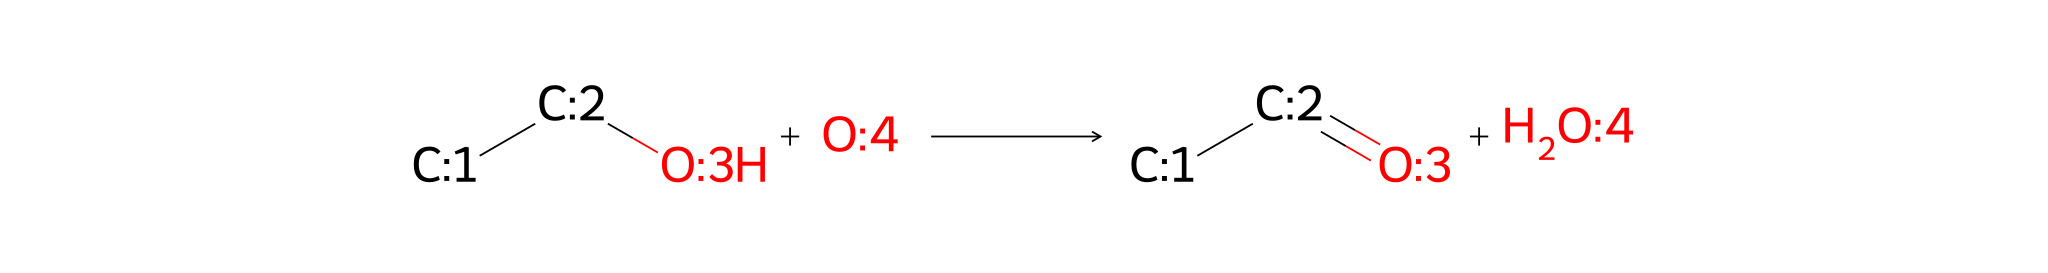

In [8]:
# Now we convert back to rsmi
from synkit.IO import graph_to_rsmi

aam = graph_to_rsmi(r, p)

svg = visualize_reaction(
    aam,
    svg=True,
    highlight_changes=True,
    legend="Oxidation",
)
display(SVG(svg))

Now we combine into 1 function

In [9]:
def mcs_aam(rsmi, node_attrs=('element',)):
    r, p = rsmi_to_graph(rsmi, drop_non_aam=False, use_index_as_atom_map=False)

    maps = mcs_networkx(
        r,
        p,
        node_attrs=node_attrs,
        edge_attrs=None,
        require_connected=False,
        prune_symmetry=True,
    )

    aams = []
    for m in maps:
        assign_atom_map_r_to_p(r, p, m)
        aam = graph_to_rsmi(r, p)
        aams.append(aam)
    return aams

**Q2 — Atom mapping via MCS: full vs partial**

Consider the following reaction SMILES:

```text
CCCl.[OH-]>>CCO.[Cl-]
c1ccccc1.ClCl>>c1ccccc1Cl.Cl
CCO>>C=C
```
For each reaction, can we recover a full atom map using MCS-based alignment, or only a partial atom map?
Explain why.

---

<details> <summary><b>Solution:</b></summary>

```python
aams = []
rsmis = ['CCCl.[OH-]>>CCO.[Cl-]', 'c1ccccc1.ClCl>>c1ccccc1Cl.Cl', 'CCO>>C=C']
for rsmi in rsmis:
    aam = mcs_aam(rsmi)
    print(aam)
    aams.append(aam)
    
```

Output

```text
['C([CH3:1])[Cl:3].[OH-:4]>>C([CH3:1])[OH:4].[Cl-:3]']
['Cl[Cl:7].[cH:1]1[cH:2][cH:3][cH:4][cH:5][cH:6]1>>Cl[c:6]1[cH:1][cH:2][cH:3][cH:4][cH:5]1.[ClH:7]', '[Cl:7][Cl:8].[cH:1]1[cH:2][cH:3][cH:4][cH:5][cH:6]1>>Cl[c:6]1[cH:1][cH:2][cH:3][cH:4][cH:5]1.[ClH:8]']
['O[CH2:2][CH3:1]>>[CH2:1]=[CH2:2]']
```

All three reactions yield **partial atom maps only**.

This is because:
- **Connectivity changes** (bond breaking/forming) prevent full graph isomorphism.
- **Stoichiometric imbalance** (missing species) leaves some atoms unmappable.

</details>

### 1.2. Attention-guided atom mapping

**RXNMapper** extracts atom correspondences from **Transformer attention** learned on reaction SMILES with a masked-language objective (BERT family). It is **unsupervised** and does not require gold atom maps.

Write a reaction as a token sequence $x=(x_1,\dots,x_T)$ with reactant and product atom tokens. During pretraining the model minimizes the masked-token objective:

$$
\min_\theta \; \mathbb{E}\!\left[-\log p_\theta\big(x_{\mathcal{M}}\mid x_{\setminus\mathcal{M}}\big)\right].
$$

At inference we extract an attention alignment matrix between reactant and product atom tokens:

$$
A \in \mathbb{R}_{\ge 0}^{m\times n},\qquad
A_{ij} := \mathrm{Attn}(r_i \to p_j),
$$

(typically from a chosen head/layer and optionally sharpened). Atom mapping is then posed as a maximum-weight assignment over admissible matchings $\Pi$:

$$
\mu = \arg\max_{\mu\in\Pi}\sum_{i=1}^{m} A_{i,\mu(i)},
$$

where \(\Pi\) enforces lightweight chemical constraints (element consistency, optional charge checks). Because the assignment is driven by attention, **bond-order preservation is not enforced**, so RXNMapper tolerates bond formation/cleavage and order changes.

Typical RXNMapper outputs:

- `mapped_rxn`: reaction SMILES annotated with atom-map indices induced by \(\mu\),  
- `confidence`: a scalar summary of alignment consistency (higher → more reliable).

We adopt this attention-guided strategy following the Molecular Transformer framework [4] and RXNMapper [5].

In [10]:
from typing import Tuple, Optional


def rxnmapper_map(rxn: str) -> Tuple[Optional[str], Optional[float]]:
    if not _HAS_RXNMAPPER:
        return None, None
    mapper = RXNMapper()
    out = mapper.get_attention_guided_atom_maps([rxn])
    mapped = out[0].get("mapped_rxn", None)
    conf = out[0].get("confidence", None)
    return mapped, conf


rsmis = ['CCCl.[OH-]>>CCO.[Cl-]', 'c1ccccc1.ClCl>>c1ccccc1Cl.Cl', 'CCO>>C=C']

if _HAS_RXNMAPPER:
    for rxn in rsmis:
        mapped, conf = rxnmapper_map(rxn)
        print(f"conf={conf:.3f} | {mapped}")
else:
    print("rxnmapper not available; install with: pip install rxnmapper")

conf=0.996 | [CH3:1][CH2:2][Cl:4].[OH-:3]>>[CH3:1][CH2:2][OH:3].[Cl-:4]
conf=0.373 | [Cl:1][Cl:2].[cH:3]1[cH:4][cH:5][cH:6][cH:7][cH:8]1>>[ClH:1].[Cl:2][c:3]1[cH:4][cH:5][cH:6][cH:7][cH:8]1
conf=0.906 | O[CH2:2][CH3:1]>>[CH2:1]=[CH2:2]


(2-its-graph-construction)=
## 2. Imaginary Transition State
The **Imaginary Transition State (ITS)** [5] (or Condensed Graph of the Reaction [6]) is a compact, chemistry-oriented way to represent *what changes* in a reaction by **superimposing reactants and products via an atom-atom map**.

Think of the ITS as a single graph whose **nodes are atom-map labels** (one node per mapped atom) and whose **edges record the bond before and after the reaction**. Reading the ITS tells you, at a glance, which bonds are preserved, broken or formed.

---


Given a balanced reaction and an atom map $\alpha$ (a bijection between reactant and product atoms):

1. Let the ITS node set be the atom-map labels
   $$
   V=\{a_1,\dots,a_M\}
   $$

2. For each unordered pair of nodes \((i,j)\) read the bond order in reactants and in products:
   $$
   br_{ij}=\text{bond order of atoms mapped to }a_i,a_j\ \text{in reactants (or }0\text{ if absent)},
   $$
   $$
   bp_{ij}=\text{bond order of atoms mapped to }a_i,a_j\ \text{in products (or }0\text{ if absent)}.
   $$

3. Add an ITS edge between \(i\) and \(j\) labelled with the pair
   $$
   (br_{ij},\,bp_{ij}).
   $$

4. The **reaction center** is simply the set of edges with a change:
   $$
   E_{\mathrm{rc}}=\{(i,j):\; br_{ij}\ne bp_{ij}\}.
   $$

---

How to read the ITS (chemical rules of thumb)

- An edge labelled (1,1) — bond preserved (single → single).  
- (1,0) — bond **broken** (present in reactants, absent in products).  
- (0,1) — bond **formed** (new bond in products).  
- (2,1) or (1.5,1.5) — bond order **changed** (double→single, or aromatic preserved).  
- Nodes keep atom identity via labels (element, charge, hybridization if desired) so you can tell *which atom* changed connectivity.

---

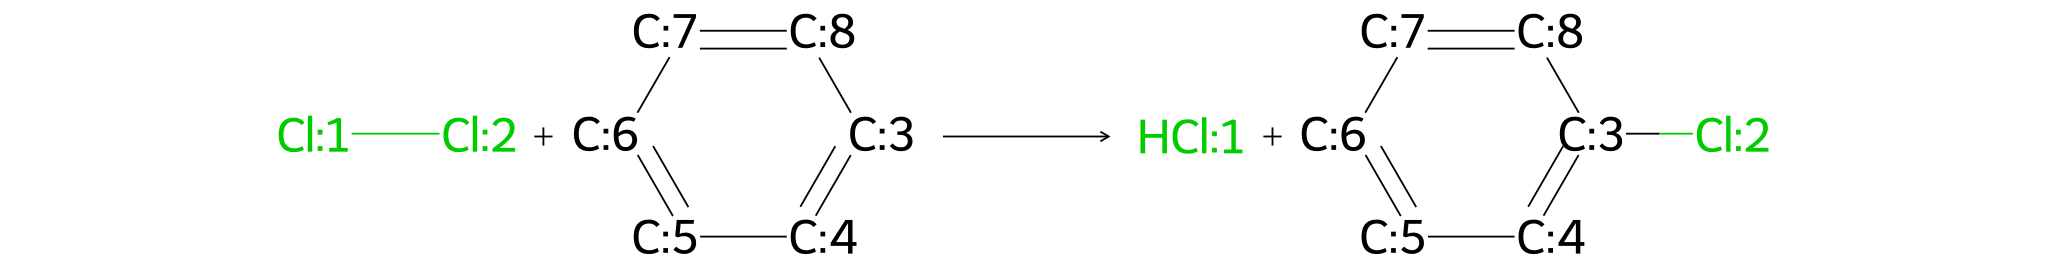

🔹 Nodes and their attributes:
  Node 1: {'element': 'Cl', 'aromatic': False, 'hcount': 0, 'charge': 0, 'neighbors': ['Cl'], 'atom_map': 1}
  Node 2: {'element': 'Cl', 'aromatic': False, 'hcount': 0, 'charge': 0, 'neighbors': ['Cl'], 'atom_map': 2}
  Node 3: {'element': 'C', 'aromatic': True, 'hcount': 1, 'charge': 0, 'neighbors': ['C', 'C'], 'atom_map': 3}
  Node 4: {'element': 'C', 'aromatic': True, 'hcount': 1, 'charge': 0, 'neighbors': ['C', 'C'], 'atom_map': 4}
  Node 5: {'element': 'C', 'aromatic': True, 'hcount': 1, 'charge': 0, 'neighbors': ['C', 'C'], 'atom_map': 5}
  Node 6: {'element': 'C', 'aromatic': True, 'hcount': 1, 'charge': 0, 'neighbors': ['C', 'C'], 'atom_map': 6}
  Node 7: {'element': 'C', 'aromatic': True, 'hcount': 1, 'charge': 0, 'neighbors': ['C', 'C'], 'atom_map': 7}
  Node 8: {'element': 'C', 'aromatic': True, 'hcount': 1, 'charge': 0, 'neighbors': ['C', 'C'], 'atom_map': 8}

🔸 Edges and their attributes:
  Edge 1-2: {'order': 1.0}
  Edge 3-4: {'order': 1.5}
 

In [11]:
from synkit.IO import rsmi_to_graph
from synkit.Graph import print_graph_attributes
from synedu.Utils.rxn_vis import visualize_reaction
from synedu.Utils.its_vis import visualize_its
from IPython.display import SVG

rsmi = '[Cl:1][Cl:2].[cH:3]1[cH:4][cH:5][cH:6][cH:7][cH:8]1>>[ClH:1].[Cl:2][c:3]1[cH:4][cH:5][cH:6][cH:7][cH:8]1'

svg = visualize_reaction(
    rsmi,
    svg=True,
    highlight_changes=True,
    legend="Se",
)
display(SVG(svg))
r, p = rsmi_to_graph(rsmi)
print_graph_attributes(r)

In [12]:
import networkx as nx
from typing import Any, List, Optional, Tuple


def _get_edge_order(G: nx.Graph, u: Any, v: Any, order_key: str = "order") -> float:
    ed = G.get_edge_data(u, v)
    if not ed:
        return 0.0
    val = ed.get(order_key, 0.0)
    try:
        return float(val)
    except (TypeError, ValueError):
        return 0.0


def build_its(
    G_r: nx.Graph,
    G_p: nx.Graph,
    *,
    atom_map_key: str = "atom_map",
    node_attrs: Optional[List[str]] = None,
    order_key: str = "order",
    include_zero_edges: bool = False,
    require_element_match: bool = True,
) -> Tuple[nx.Graph, List[Tuple[int, int]]]:

    map_r = {
        data[atom_map_key]: n
        for n, data in G_r.nodes(data=True)
        if atom_map_key in data
    }
    map_p = {
        data[atom_map_key]: n
        for n, data in G_p.nodes(data=True)
        if atom_map_key in data
    }
    all_maps = sorted(set(map_r.keys()) | set(map_p.keys()))

    # gather node attribute keys if not provided
    if node_attrs is None:
        keys = set()
        for _, d in G_r.nodes(data=True):
            keys.update(d.keys())
        for _, d in G_p.nodes(data=True):
            keys.update(d.keys())
        keys.discard(atom_map_key)
        keys.discard("element")
        node_attrs = sorted(keys)

    ITS = nx.Graph()
    ITS.add_nodes_from(all_maps)

    # populate node attributes (element + requested attrs)
    for m in all_maps:
        r_node = map_r.get(m)
        p_node = map_p.get(m)

        r_data = G_r.nodes[r_node] if r_node is not None else {}
        p_data = G_p.nodes[p_node] if p_node is not None else {}

        # element handling
        elem_r = r_data.get("element")
        elem_p = p_data.get("element")
        if elem_r is not None and elem_p is not None and elem_r != elem_p:
            if require_element_match:
                raise ValueError(
                    f"Element mismatch for atom_map {m}: reactant={elem_r!r} vs product={elem_p!r}"
                )
            ITS.nodes[m]["element"] = (elem_r, elem_p)
        else:
            ITS.nodes[m]["element"] = elem_r if elem_r is not None else elem_p

        # other attributes as (val_r, val_p)
        for key in node_attrs:
            ITS.nodes[m][key] = (r_data.get(key), p_data.get(key))

    # build ITS edges with single 'order' tuple (br, bp)
    for i_idx, j_idx in (
        (i, j) for idx, i in enumerate(all_maps) for j in all_maps[idx + 1 :]
    ):
        r_u = map_r.get(i_idx)
        r_v = map_r.get(j_idx)
        br = (
            _get_edge_order(G_r, r_u, r_v, order_key=order_key)
            if (r_u is not None and r_v is not None)
            else 0.0
        )

        p_u = map_p.get(i_idx)
        p_v = map_p.get(j_idx)
        bp = (
            _get_edge_order(G_p, p_u, p_v, order_key=order_key)
            if (p_u is not None and p_v is not None)
            else 0.0
        )

        if include_zero_edges or (br != 0.0 or bp != 0.0):
            ITS.add_edge(i_idx, j_idx, order=(br, bp))

    return ITS

🔹 Nodes and their attributes:
  Node 1: {'element': 'Cl', 'aromatic': (False, False), 'charge': (0, 0), 'hcount': (0, 1), 'neighbors': (['Cl'], [])}
  Node 2: {'element': 'Cl', 'aromatic': (False, False), 'charge': (0, 0), 'hcount': (0, 0), 'neighbors': (['Cl'], ['C'])}
  Node 3: {'element': 'C', 'aromatic': (True, True), 'charge': (0, 0), 'hcount': (1, 0), 'neighbors': (['C', 'C'], ['C', 'C', 'Cl'])}
  Node 4: {'element': 'C', 'aromatic': (True, True), 'charge': (0, 0), 'hcount': (1, 1), 'neighbors': (['C', 'C'], ['C', 'C'])}
  Node 5: {'element': 'C', 'aromatic': (True, True), 'charge': (0, 0), 'hcount': (1, 1), 'neighbors': (['C', 'C'], ['C', 'C'])}
  Node 6: {'element': 'C', 'aromatic': (True, True), 'charge': (0, 0), 'hcount': (1, 1), 'neighbors': (['C', 'C'], ['C', 'C'])}
  Node 7: {'element': 'C', 'aromatic': (True, True), 'charge': (0, 0), 'hcount': (1, 1), 'neighbors': (['C', 'C'], ['C', 'C'])}
  Node 8: {'element': 'C', 'aromatic': (True, True), 'charge': (0, 0), 'hcount': (1

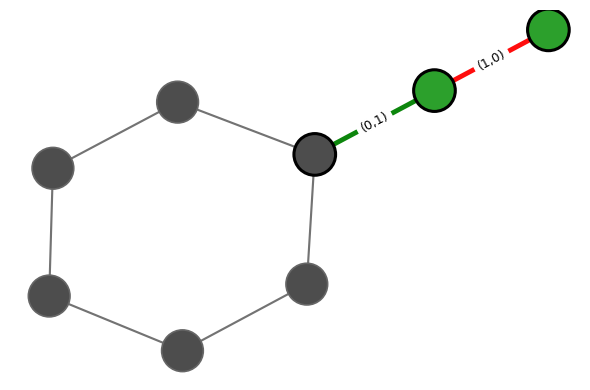

In [13]:
its = build_its(r, p)
print_graph_attributes(its)
ax = visualize_its(
    its,
    layout="kamada_kawai",
    show_edge_labels=True,
    show_node_labels=False,
    show_legends=False,
)

**Q3 — Reaction center**

Now develop function `get_reaction_center` to extract reacton center

---

<details> <summary><b>Solution:</b></summary>

```python
import networkx as nx


def get_reaction_center(
    its: nx.Graph,
    *,
    node_view: bool = False,
):
    rc_edges = []
    rc_nodes = set()

    for u, v, d in its.edges(data=True):
        br, bp = d.get("order", (0.0, 0.0))
        if br != bp:
            rc_edges.append((u, v))
            rc_nodes.update([u, v])

    if node_view:
        return rc_nodes

    rc = nx.Graph()
    rc.add_nodes_from((n, its.nodes[n]) for n in rc_nodes)
    rc.add_edges_from(
        (u, v, its.edges[u, v]) for u, v in rc_edges
    )

    return rc

```
</details>

Now we combine to 1 function `rsmi_to_its`

In [14]:
import networkx as nx


def get_reaction_center(
    its: nx.Graph,
    *,
    node_view: bool = False,
):
    rc_edges = []
    rc_nodes = set()

    for u, v, d in its.edges(data=True):
        br, bp = d.get("order", (0.0, 0.0))
        if br != bp:
            rc_edges.append((u, v))
            rc_nodes.update([u, v])

    if node_view:
        return rc_nodes

    rc = nx.Graph()
    rc.add_nodes_from((n, its.nodes[n]) for n in rc_nodes)
    rc.add_edges_from((u, v, its.edges[u, v]) for u, v in rc_edges)

    return rc


def rsmi_to_its(rsmi, core=False):
    r, p = rsmi_to_graph(rsmi)
    its = build_its(r, p)
    if core:
        return get_reaction_center(its)
    return its

(3-ensemble-atom-map)=
## 3. ITS equivalence

Now try with 3 reactions below

In [15]:
m1 = "[CH3:8][CH2:7][O:6][C:5](=[O:9])[CH2:4][C:2](=[O:3])[O:1][CH2:22][CH3:23].[O:14]=[N+:12]([O-:13])[CH:11]=[CH:10][C:15]1=[CH:16][CH:17]=[C:18]([Cl:19])[CH:20]=[CH:21]1>>[O:1]([C:2](=[O:3])[CH:4]([C:5]([O:6][CH2:7][CH3:8])=[O:9])[CH:10]([CH2:11][N+:12]([O-:13])=[O:14])[C:15]1=[CH:16][CH:17]=[C:18]([Cl:19])[CH:20]=[CH:21]1)[CH2:22][CH3:23]"
m2 = "[O:1]=[N+:2]([O-:3])[CH:4]=[CH:5][c:6]1[cH:7][cH:8][c:9]([Cl:10])[cH:11][cH:12]1.[O:13]=[C:14]([O:15][CH2:16][CH3:17])[CH2:18][C:19](=[O:20])[O:21][CH2:22][CH3:23]>>[CH2:4]([N+:2](=[O:1])[O-:3])[CH:5]([c:6]1[cH:12][cH:11][c:9]([cH:8][cH:7]1)[Cl:10])[CH:18]([C:14](=[O:13])[O:15][CH2:16][CH3:17])[C:19](=[O:20])[O:21][CH2:22][CH3:23]"
m3 = "[CH3:1][CH2:2][O:3][C:4](=[O:5])[CH2:6][C:7](=[O:8])[O:9][CH2:10][CH3:11].[O:12]=[N+:13]([O-:14])[CH:15]=[CH:16][C:17]1=[CH:18][CH:19]=[C:20]([CH:21]=[CH:22]1)[Cl:23]>>[O:3]([C:4](=[O:5])[CH:6]([C:7]([O:9][CH2:10][CH3:11])=[O:8])[CH:16]([CH2:15][N+:13]([O-:14])=[O:12])[C:17]1=[CH:18][CH:19]=[C:20]([Cl:23])[CH:21]=[CH:22]1)[CH2:2][CH3:1]"

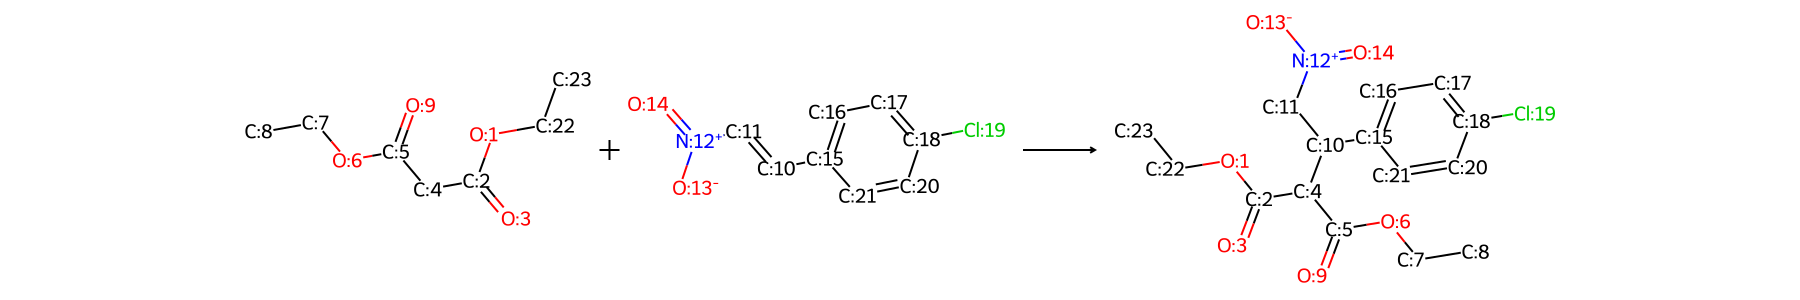

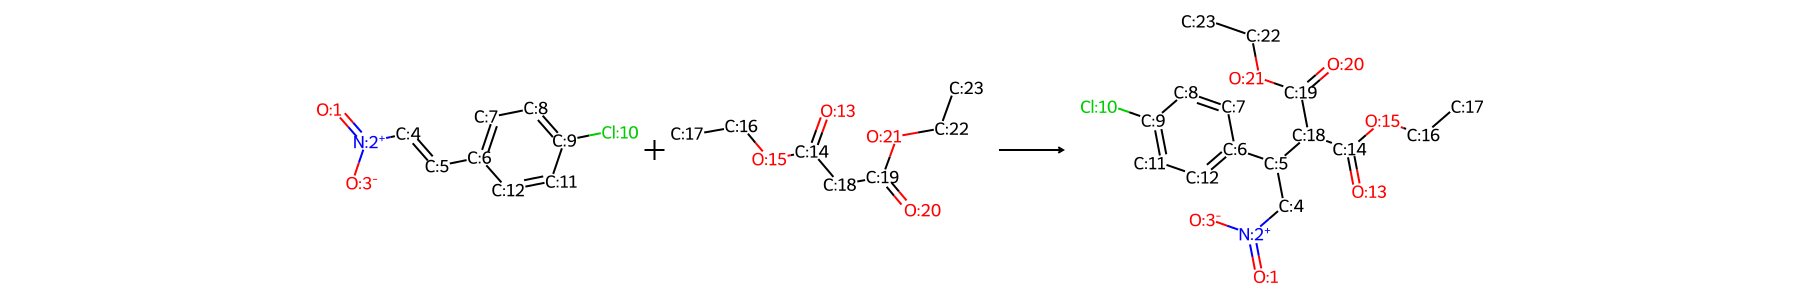

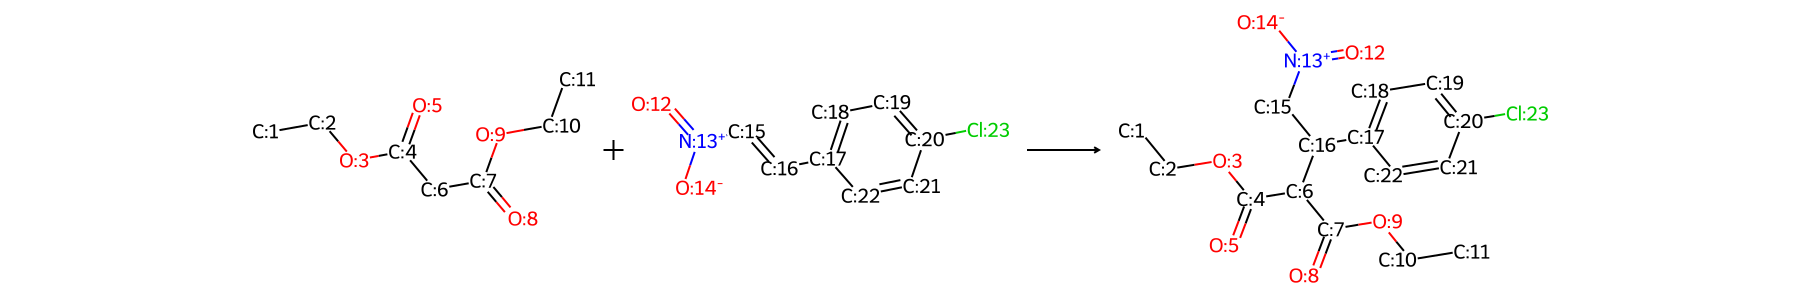

In [16]:
svg1 = visualize_reaction(
    m1,
    svg=True,
    highlight_changes=True,
    legend="aam1",
)
svg2 = visualize_reaction(
    m2,
    svg=True,
    highlight_changes=True,
    legend="aam2",
)
svg3 = visualize_reaction(
    m3,
    svg=True,
    highlight_changes=True,
    legend="aam3",
)
display(SVG(svg1))
display(SVG(svg2))
display(SVG(svg3))

Even for experienced chemists, it is non-trivial to determine whether three atom mappings are equivalent.

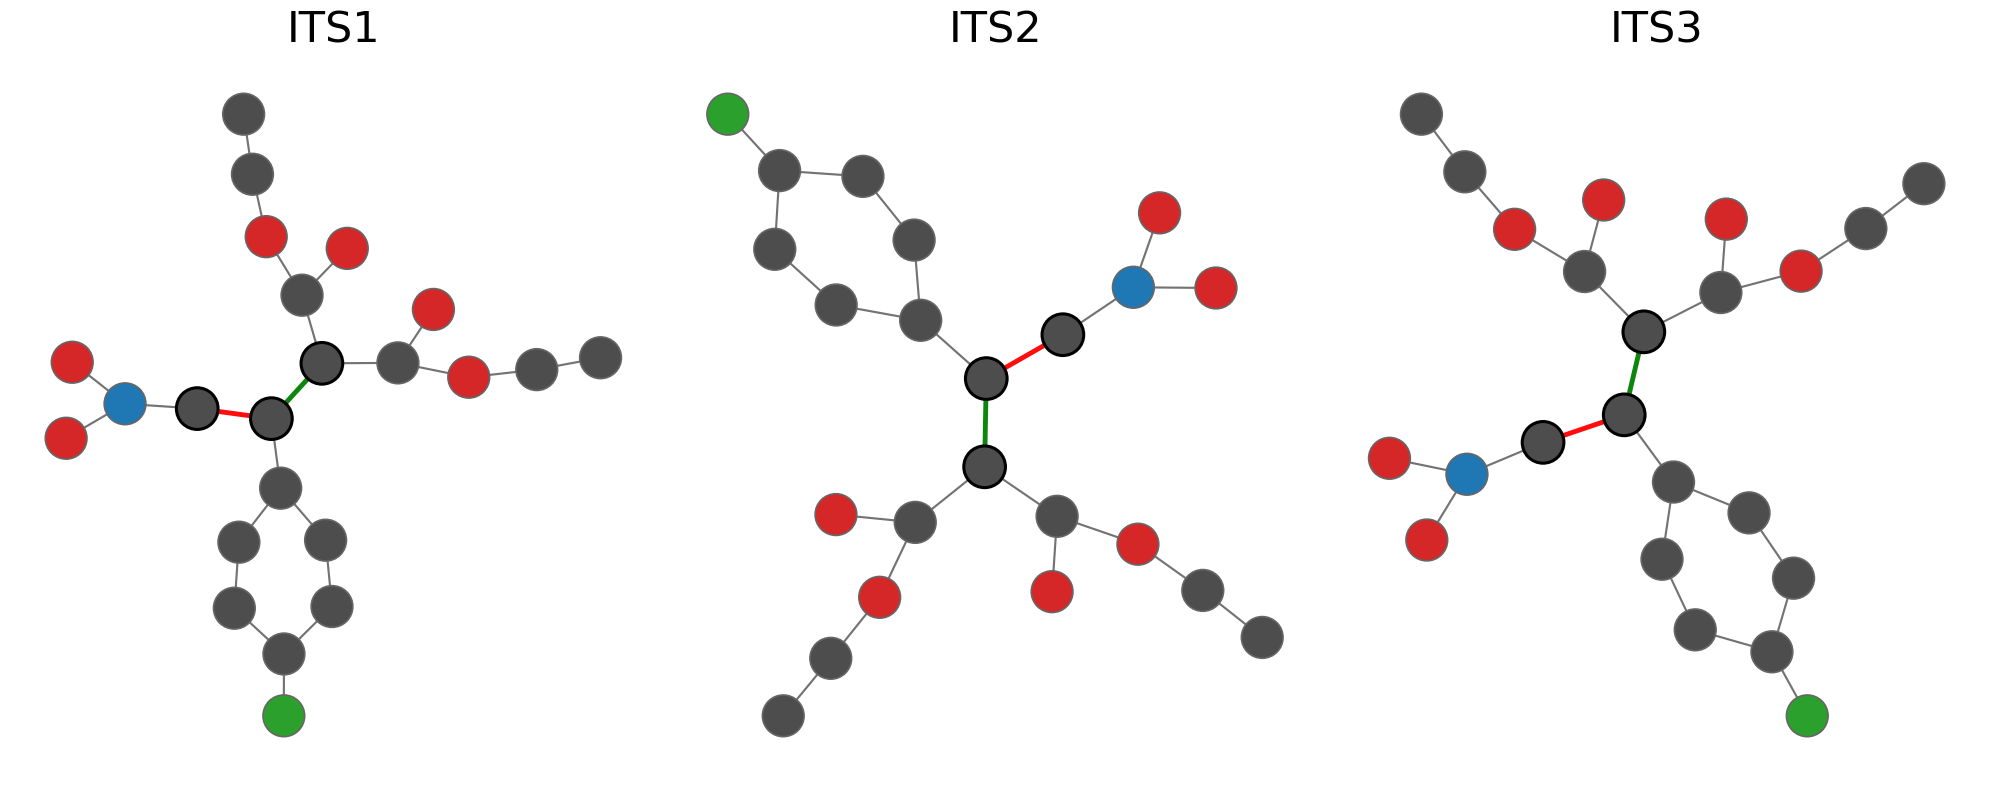

In [17]:
import matplotlib.pyplot as plt

its1 = rsmi_to_its(m1)
its2 = rsmi_to_its(m2)
its3 = rsmi_to_its(m3)


fig, axes = plt.subplots(1, 3, figsize=(20, 8))
visualize_its(
    its1,
    ax=axes[0],
    title="ITS1",
    font_size=30,
    show_node_labels=False,
    show_edge_labels=False,
)
visualize_its(
    its2,
    ax=axes[1],
    title="ITS2",
    font_size=30,
    show_node_labels=False,
    show_edge_labels=False,
)
visualize_its(
    its3,
    ax=axes[2],
    title="ITS3",
    font_size=30,
    show_node_labels=False,
    show_edge_labels=False,
)
plt.tight_layout()
plt.show()

While atom-map equivalence is hard to judge directly, the corresponding ITS graphs are equivalent if and only if they are isomorphic, a concept we already encountered in **S02**.

In [18]:
import networkx as nx
from networkx.algorithms.isomorphism import GraphMatcher, generic_node_match


def its_isomorphic(
    G1: nx.Graph,
    G2: nx.Graph,
    *,
    node_attrs=("element", "aromatic", "charge", "hcount"),
    edge_attrs=("order",),
) -> bool:
    """
    Check whether two ITS graphs are isomorphic.

    Node attributes are compared by exact equality
    (including tuple-valued ITS attributes).
    """

    # --- node matcher (exact match for all attributes) ---
    node_match = generic_node_match(
        list(node_attrs),
        [None] * len(node_attrs),
        [lambda a, b: a == b] * len(node_attrs),
    )

    # --- edge matcher ---
    def edge_match(d1, d2):
        return all(d1.get(a) == d2.get(a) for a in edge_attrs)

    gm = GraphMatcher(
        G1,
        G2,
        node_match=node_match,
        edge_match=edge_match,
    )

    return gm.is_isomorphic()

In [19]:
print("Checking ITS graph equivalence via graph isomorphism")
print("- ITS₁ vs ITS₂:", its_isomorphic(its1, its2))
print("- ITS₁ vs ITS₃:", its_isomorphic(its1, its3))

Checking ITS graph equivalence via graph isomorphism
- ITS₁ vs ITS₂: True
- ITS₁ vs ITS₃: True


**Q4 — Atom-map equivalence**

Consider the dataset `data/reaction_maps.csv`
Each reaction is associated with three atom-mapped SMILES, generated by different atom-mapping methods (`map1`, `map2`, `map3`).


Tasks:
1. Write a function that determines whether three atom-mapped reactions are equivalent, by converting each to an ITS graph and checking graph isomorphism.
2. Apply this function to all reactions in the dataset.
3. Record, for each reaction, whether the three mappings are equivalent.

---

<details> <summary><b>Solution:</b></summary>

```python
import pandas as pd
def is_maps_eq(
    maps,
    *,
    node_attrs=("element", "aromatic", "charge", "hcount"),
    edge_attrs=("order",),
):
    """
    Check whether multiple mapped reactions are equivalent
    by comparing their ITS graphs up to isomorphism.
    """
    its_list = [rsmi_to_its(m) for m in maps]

    ref = its_list[0]
    for its in its_list[1:]:
        if not its_isomorphic(
            ref,
            its,
            node_attrs=node_attrs,
            edge_attrs=edge_attrs,
        ):
            return False
    return True

data = pd.read_csv('./data/reaction_maps.csv').to_dict('records')

for entry in data:
    maps = [entry["map1"], entry["map2"], entry["map3"]]
    entry["is_eq"] = is_maps_eq(maps)
data = pd.DataFrame(data)
data.head()
```

</details>

(5-quiz)=
## 4. Quiz

1. **MCS limitations**  
   Why can maximum common substructure (MCS) fail for reactions with multiple components or high symmetry?

2. **Attention vs structure**  
   What key information does RXNMapper use that is *not* explicitly enforced by graph-based MCS?

3. **ITS intuition**  
   In one sentence, explain what an ITS graph represents chemically.

4. **Atom-map ambiguity**  
   Why can two atom-mapped SMILES look different but still describe the same reaction?

5. **Canonical comparison**  
   How does ITS isomorphism remove dependence on atom-map numbers?

(4-discussion)=
## 5. Discussion

- **MCS** is a principled alignment baseline, but struggles with multi-component reactions, molecular symmetry, and unbalanced equations.
- **RXNMapper** offers a strong, practical solution by leveraging learned attention patterns and providing confidence estimates.
- **ITS graphs** compactly encode bond changes, abstracting away atom-map labeling details.
- **ITS isomorphism** provides a clean, map-number-invariant criterion for comparing atom mappings across methods.

(6-references)=
## 6. References

1. <a id="ref-1"></a> RDKit documentation: https://www.rdkit.org/docs/  
2. <a id="ref-2"></a> NetworkX documentation: https://networkx.org/documentation/stable/
3. <a id="ref-3"></a> **SynKit**: A graph-based framework for rule-based reaction modeling  
   Phan, T.-L. *et al.* *Journal of Chemical Information and Modeling* (2025).  
   https://doi.org/10.1021/acs.jcim.5c02123
4. <a id="ref-4"></a> Schwaller, P. *et al.*  
   *Molecular Transformer: A Model for Uncertainty-Calibrated Chemical Reaction Prediction.*  
   **ACS Central Science** (2019).  
   https://doi.org/10.1021/acscentsci.9b00576

5. <a id="ref-5"></a> Schwaller, P. *et al.*  
   *Extraction of organic chemistry grammar from unsupervised learning of chemical reactions (RXNMapper).*  
   **Science Advances** (2021).  
   https://doi.org/10.1126/sciadv.abe4166

6. <a id="ref-6"></a> Phan, T.-L.; Weinbauer, K.; González Laffitte, M. E.; Pan, Y.; Merkle, D.; Andersen, J. L.; Fagerberg, R.; Flamm, C.; Stadler, P. F.  
   *SynTemp: Efficient Extraction of Graph-Based Reaction Rules from Large-Scale Reaction Databases.*  
   **Journal of Chemical Information and Modeling** (2025).  
   https://doi.org/10.1021/acs.jcim.4c01795

7. <a id="ref-7"></a> Nugmanov, R. I.; Mukhametgaleev, R. N.; Akhmetshin, T.; Gimadiev, T. R.; Afonina, V. A.; Madzhidov, T. I.; Varnek, A.  
   *CGRtools: Python Library for Molecule, Reaction, and Condensed Graph of Reaction Processing.*  
   **Journal of Chemical Information and Modeling** (2019), **59**, 2516–2521.  
   https://doi.org/10.1021/acs.jcim.9b00102
